In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv('data/students.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [5]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

### No missing values

In [10]:
df.duplicated().sum()

0

### No duplicates


In [ ]:
for column in df.columns:
    
    print(f"Unique values in {column}: {df[column].nunique()}")
    print("-----------------------------------------------------")


Unique values in gender: 2
-----------------------------------------------------
Unique values in race/ethnicity: 5
-----------------------------------------------------
Unique values in parental level of education: 6
-----------------------------------------------------
Unique values in lunch: 2
-----------------------------------------------------
Unique values in test preparation course: 2
-----------------------------------------------------
Unique values in math score: 81
-----------------------------------------------------
Unique values in reading score: 72
-----------------------------------------------------
Unique values in writing score: 77
-----------------------------------------------------


In [17]:
for column in df.columns:
    if df[column].dtype == 'object':
        print(f"Column: {column}")
        print(f"Unique values in {column}: {df[column].unique()}")
        print("-----------------------------------------------------")

Column: gender
Unique values in gender: ['female' 'male']
-----------------------------------------------------
Column: race/ethnicity
Unique values in race/ethnicity: ['group B' 'group C' 'group A' 'group D' 'group E']
-----------------------------------------------------
Column: parental level of education
Unique values in parental level of education: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
-----------------------------------------------------
Column: lunch
Unique values in lunch: ['standard' 'free/reduced']
-----------------------------------------------------
Column: test preparation course
Unique values in test preparation course: ['none' 'completed']
-----------------------------------------------------


In [19]:
df.info()   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [18]:
numeric_features = [column for column in df.columns if df[column].dtype in ['int64', 'float64']]
categorical_features = [column for column in df.columns if df[column].dtype == 'object']
print(f"Numeric features: {numeric_features}")
print(f"Categorical features: {categorical_features}")

Numeric features: ['math score', 'reading score', 'writing score']
Categorical features: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


### Feature Engineering

In [20]:
df.head(2)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


In [21]:
df['total score'] = df['math score'] + df['reading score'] + df['writing score']
df['average score'] = df['total score'] / 3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [27]:
math_full=df[df['math score']==100]['math score'].count()
print(f"Number of students with full math score: {math_full}")
reading_less_30=df[df['reading score']<30]['reading score'].count()
print(f"Number of students with reading score less than 30: {reading_less_30}")

Number of students with full math score: 7
Number of students with reading score less than 30: 8


<Axes: xlabel='average score', ylabel='Count'>

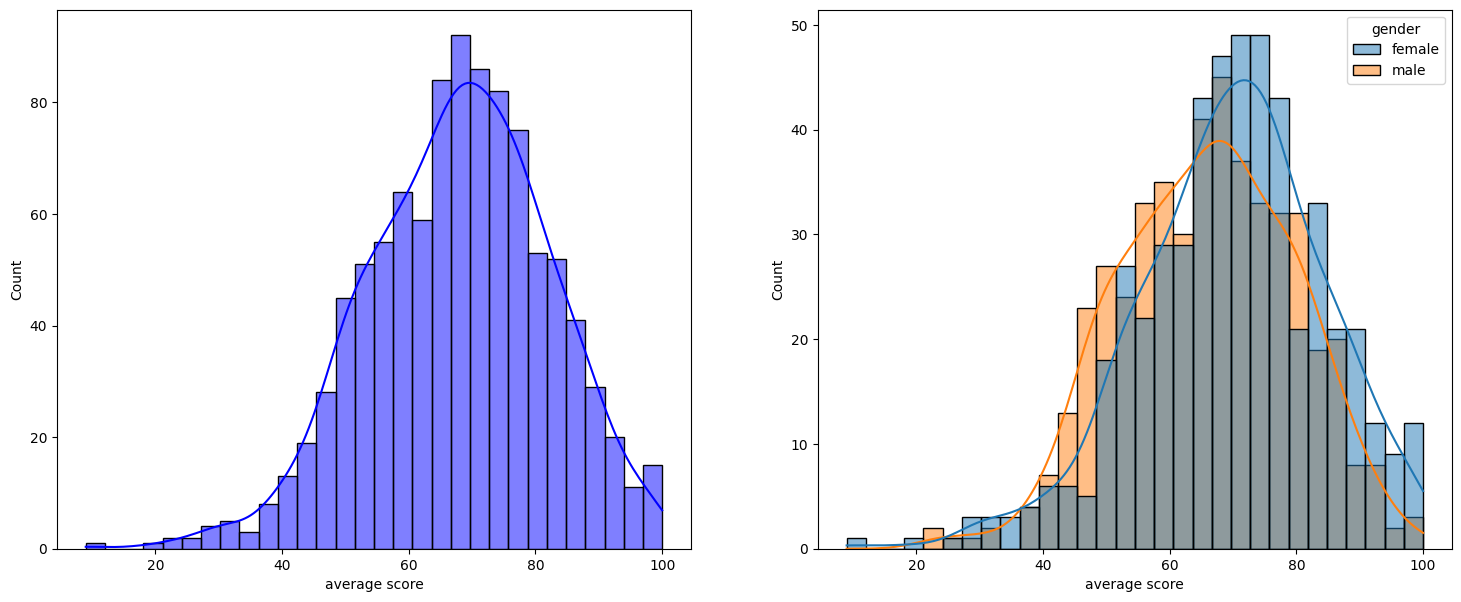

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
plt.subplot(1, 2, 1)
sns.histplot(df,x='average score', bins=30, kde=True, color='blue')

plt.subplot(1, 2, 2)
sns.histplot(df,x='average score', bins=30, kde=True, hue='gender')

#####  Insights
- Female students tend to perform well then male students.

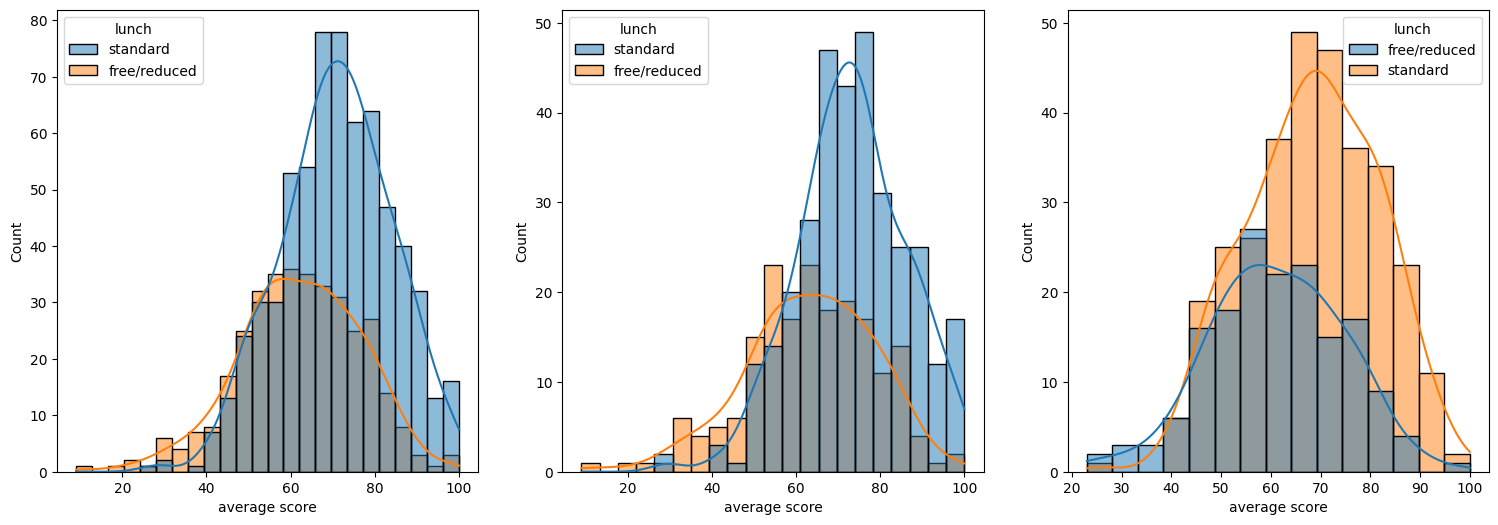

In [34]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df,x='average score',kde=True,hue='lunch')
plt.subplot(142)
sns.histplot(data=df[df.gender=='female'],x='average score',kde=True,hue='lunch')
plt.subplot(143)
sns.histplot(data=df[df.gender=='male'],x='average score',kde=True,hue='lunch')
plt.show()

#####  Insights
- Standard lunch helps perform well in exams.
- Standard lunch helps perform well in exams be it a male or a female.

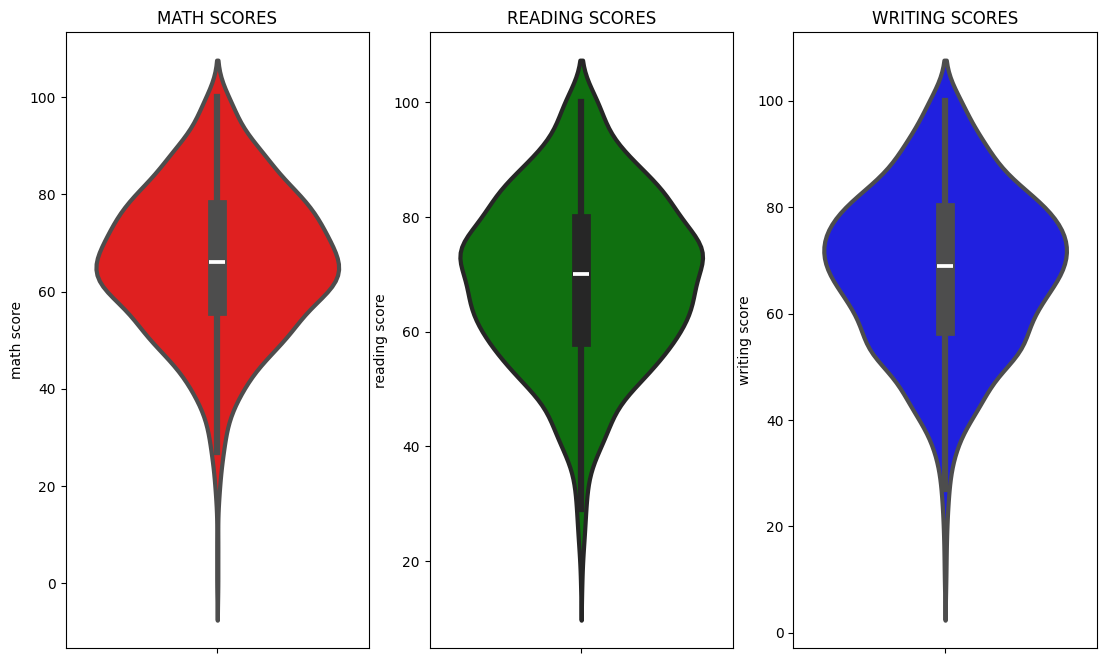

In [35]:

plt.figure(figsize=(18,8))
plt.subplot(1, 4, 1)
plt.title('MATH SCORES')
sns.violinplot(y='math score',data=df,color='red',linewidth=3)
plt.subplot(1, 4, 2)
plt.title('READING SCORES')
sns.violinplot(y='reading score',data=df,color='green',linewidth=3)
plt.subplot(1, 4, 3)
plt.title('WRITING SCORES')
sns.violinplot(y='writing score',data=df,color='blue',linewidth=3)
plt.show()

#### Insights
- From the above three plots its clearly visible that most of the students score in between 60-80 in Maths whereas in reading and writing most of them score from 50-80